# 02 — OpenSurvey EDA + 외부 검증 (Phase 1.1 + 1.2)

## 목적
한국 카페 시장 인구통계 × 메뉴/카페/시간대 prior를 추출하고, 외부 reference와 정량 비교해 합성 데이터의 ground truth를 확정한다.

## 입력
- `kr_synthetic/opensurvey_cafe_2025_synthetic.csv` (2,000명 × 148문항)
- `kr_synthetic/rec_users.csv` (사용자 인구통계 마스터)
- `kr_synthetic/rec_items.csv` (한국 카페 메뉴 30개 메타)
- 검증 reference (옵션):
  - Bread Basket EDA 결과 (`output/transactions_clean.csv` — 노트북 01 산출)
  - Coffee Sales Dataset (`coffee sales dataset/Coffe_sales.csv`)

## 출력
- `output/prior_demographics.csv`            P(gender, age_band, job, area)
- `output/prior_menu_by_demographic.csv`     P(menu_category | gender, age_band)
- `output/prior_brand_by_demographic.csv`    P(cafe_brand | demographic)
- `output/prior_time_by_demographic.csv`     P(time_period | demographic)
- `output/prior_menu_by_time.csv`            P(menu | time_period)
- `output/validation_report.md`              외부 reference 검증 결과

## 데이터 업로드
**옵션 A — 직접 업로드**: 좌측 패널에서 `kr_synthetic/` 폴더 통째로 압축 후 업로드 → 압축 풀기.
**옵션 B — Drive 마운트** (권장): Drive에 `Adaptive_Kiosk/create_data/raw/kr_synthetic/`로 폴더 둠.

본 노트북 0번 셀에서 `USE_GDRIVE` 토글로 선택.

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Imports & Paths

In [112]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Drive 사용 기본 ON
USE_GDRIVE = True

if USE_GDRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    # ⚠️ 폴더명 안 공백 주의: '광운대 ' (광운대 뒤에 공백 1칸) 그대로 유지
    BASE_DIR = Path("/content/drive/MyDrive/광운대 /26년도 캡스톤/data")
else:
    BASE_DIR = Path("/content")

RAW_DIR    = BASE_DIR / "kr_synthetic"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OPENSURVEY_PATH = RAW_DIR / "opensurvey_cafe_2025_synthetic.csv"
USERS_PATH      = RAW_DIR / "rec_users.csv"
ITEMS_PATH      = RAW_DIR / "rec_items.csv"

print("BASE_DIR :", BASE_DIR)
print("RAW_DIR  :", RAW_DIR)
print("OUTPUT   :", OUTPUT_DIR)
for p in (OPENSURVEY_PATH, USERS_PATH, ITEMS_PATH):
    print(f"  {p.name:50s} exists={p.exists()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR : /content/drive/MyDrive/광운대 /26년도 캡스톤/data
RAW_DIR  : /content/drive/MyDrive/광운대 /26년도 캡스톤/data/kr_synthetic
OUTPUT   : /content/drive/MyDrive/광운대 /26년도 캡스톤/data/output
  opensurvey_cafe_2025_synthetic.csv                 exists=True
  rec_users.csv                                      exists=True
  rec_items.csv                                      exists=True


In [113]:
# ─── Colab 한글 폰트 (matplotlib) ──────────────────────────────
# 최초 1회: 나눔고딕 설치. 이미 설치돼 있으면 즉시 통과.
# 설치 후 런타임 재시작은 불필요 (font_manager 캐시만 갱신).

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager as fm
import os, shutil, subprocess

FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

if not os.path.exists(FONT_PATH):
    print("[font] NanumGothic 설치 중...")
    subprocess.run(["apt-get", "-qq", "install", "fonts-nanum"], check=False)
    # mpl 캐시 무력화 → 새 폰트 인식
    cache = mpl.get_cachedir()
    if os.path.isdir(cache):
        shutil.rmtree(cache, ignore_errors=True)

# 폰트 등록 + rcParams
fm.fontManager.addfont(FONT_PATH)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지

# 확인
print("[font] 적용됨:", plt.rcParams["font.family"])


[font] 적용됨: ['NanumGothic']


## 1. Load (한글 인코딩 주의)

OpenSurvey CSV는 cp949(또는 euc-kr) 추정. 실패 시 utf-8 / utf-8-sig 순으로 시도.

In [114]:
def read_csv_smart(path: Path) -> pd.DataFrame:
    last_err = None
    for enc in ("cp949", "euc-kr", "utf-8-sig", "utf-8"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError as e:
            last_err = e
            continue
    raise RuntimeError(f"Cannot read {path}: {last_err}")

survey_df = read_csv_smart(OPENSURVEY_PATH)
users_df  = read_csv_smart(USERS_PATH)
items_df  = read_csv_smart(ITEMS_PATH)

print("survey:", survey_df.shape)
print("users :", users_df.shape)
print("items :", items_df.shape)
survey_df.head(2)

survey: (2000, 148)
users : (2000, 8)
items : (30, 10)


,respondent_id,sex,age,age_10,age_5,job_group,job,area,area_group,area_capital,SQ3_에스프레소,SQ3_아메리카노,SQ3_카페라떼,SQ3_카푸치노,SQ3_콜드브루,...,뺵다방_Q9_티차류,뺵다방_Q9_스무디프라페,뺵다방_Q9_주스에이드,뺵다방_Q8_평일아침,뺵다방_Q8_평일오전,뺵다방_Q8_평일점심,뺵다방_Q8_평일오후,뺵다방_Q8_평일저녁,뺵다방_Q8_평일밤,뺵다방_Q8_주말아침,뺵다방_Q8_주말오전,뺵다방_Q8_주말점심,뺵다방_Q8_주말오후,뺵다방_Q8_주말저녁,뺵다방_Q8_주말밤
0,R0001,남,51,50대,50~54,기타직업,무직,서울,서울,수도권,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R0002,여,40,40대,40~44,직장인,사무/기술직,경기,서울외수도권,수도권,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
print("[users] columns:", list(users_df.columns))
print("\n[items] columns:", list(items_df.columns))
print("\n[survey] columns count:", len(survey_df.columns))
print("survey columns sample:", list(survey_df.columns[:30]))

[users] columns: ['user_id', 'gender', 'age', 'age_band', 'age_5', 'job', 'area', 'reg_date']

[items] columns: ['item_id', 'item_name', 'category', 'is_hot', 'is_ice', 'is_coffee', 'caffeine_mg', 'sugar_g', 'calorie_kcal', 'base_price']

[survey] columns count: 148
survey columns sample: ['respondent_id', 'sex', 'age', 'age_10', 'age_5', 'job_group', 'job', 'area', 'area_group', 'area_capital', 'SQ3_에스프레소', 'SQ3_아메리카노', 'SQ3_카페라떼', 'SQ3_카푸치노', 'SQ3_콜드브루', 'SQ3_콜드브루라떼', 'SQ3_드립핸드드립', 'SQ3_달콤한커피류', 'SQ3_얼음갈린커피', 'SQ3_기본티', 'SQ3_달콤한티', 'SQ3_과일티에이드', 'SQ3_얼음갈린티', 'SQ3_스무디쉐이크', 'SQ3_주스에이드', 'SQ4_1순위', 'SQ4_2순위', 'SQ4_3순위', 'visit_스타벅스', '스타벅스_Q9_에스프레소베이스']


## 2. 컬럼 그룹화

OpenSurvey는 컬럼 패턴이 복잡 — 그룹별로 나눠 분석한다.

- 인구통계: `respondent_id`, `sex`, `age`, `age_10`, `age_5`, `job_group`, `job`, `area`, `area_group`, `area_capital`
- SQ3_*: 평소 자주 마시는 음료 (binary multi-select)
- SQ4_1/2/3순위: 자주 가는 카페 브랜드 (single)
- visit_<카페>: 그 카페 방문 여부 (binary)
- <카페>_Q9_<메뉴>: 그 카페에서 마시는 메뉴 (binary)
- <카페>_Q8_<시간대>: 그 카페 방문 시간대 (binary)

In [116]:
demo_cols   = [c for c in survey_df.columns
               if c in {"respondent_id","sex","age","age_10","age_5",
                         "job_group","job","area","area_group","area_capital"}]
sq3_cols    = [c for c in survey_df.columns if c.startswith("SQ3_")]
sq4_cols    = [c for c in survey_df.columns if c.startswith("SQ4_")]
visit_cols  = [c for c in survey_df.columns if c.startswith("visit_")]
q9_cols     = [c for c in survey_df.columns if "_Q9_" in c]
q8_cols     = [c for c in survey_df.columns if "_Q8_" in c]

print(f"demo: {len(demo_cols)}  sq3: {len(sq3_cols)}  sq4: {len(sq4_cols)}"
      f"  visit: {len(visit_cols)}  Q9: {len(q9_cols)}  Q8: {len(q8_cols)}")

# 카페 브랜드 / 메뉴 / 시간대 추출 (Q9·Q8 컬럼명 분해)
def split_q(col, marker):
    if marker not in col:
        return None, None
    brand, rest = col.split(marker, 1)
    return brand, rest

brands_q9   = sorted({split_q(c, '_Q9_')[0] for c in q9_cols})
menus_q9    = sorted({split_q(c, '_Q9_')[1] for c in q9_cols})
brands_q8   = sorted({split_q(c, '_Q8_')[0] for c in q8_cols})
times_q8    = sorted({split_q(c, '_Q8_')[1] for c in q8_cols})

print("\n[brands] Q9:", brands_q9)
print("[menus]  Q9:", menus_q9)
print("[times]  Q8:", times_q8)

demo: 10  sq3: 15  sq4: 3  visit: 6  Q9: 42  Q8: 72

[brands] Q9: ['메가커피', '뺵다방', '스타벅스', '이디야', '컴포즈커피', '투썸플레이스']
[menus]  Q9: ['스무디프라페', '아이스크림커피', '에스프레소베이스', '우유베이스커피', '우유베이스티', '주스에이드', '티차류']
[times]  Q8: ['주말밤', '주말아침', '주말오전', '주말오후', '주말저녁', '주말점심', '평일밤', '평일아침', '평일오전', '평일오후', '평일저녁', '평일점심']


## 3. 인구통계 분포 — `prior_demographics.csv`

In [117]:
for col in ["sex", "age_10", "job_group", "area_group"]:
    print(f"\n[{col}]")
    print(survey_df[col].value_counts(dropna=False).to_string())


[sex]
sex
남    1026
여     974

[age_10]
age_10
50대    604
40대    531
30대    465
20대    400

[job_group]
job_group
직장인       1264
기타직업       359
전업주부       192
대학(원)생     182
청소년          3

[area_group]
area_group
서울외수도권    574
서울        499
기타지역      474
5대광역시     453


In [118]:
demo_dist = (
    survey_df.groupby(["sex", "age_10", "job_group", "area_group"])
    .size().reset_index(name="count")
)
demo_dist["prob"] = demo_dist["count"] / demo_dist["count"].sum()
demo_dist.to_csv(OUTPUT_DIR / "prior_demographics.csv", index=False, encoding="utf-8-sig")
print("saved prior_demographics.csv shape:", demo_dist.shape)
demo_dist.head(10)

saved prior_demographics.csv shape: (131, 6)


,sex,age_10,job_group,area_group,count,prob
0,남,20대,기타직업,5대광역시,10,0.0050
1,남,20대,기타직업,기타지역,7,0.0035
2,남,20대,기타직업,서울,11,0.0055
3,남,20대,기타직업,서울외수도권,8,0.0040
4,남,20대,대학(원)생,5대광역시,7,0.0035
5,남,20대,대학(원)생,기타지역,3,0.0015
6,남,20대,대학(원)생,서울,5,0.0025
7,남,20대,대학(원)생,서울외수도권,4,0.0020
8,남,20대,전업주부,5대광역시,3,0.0015
9,남,20대,전업주부,기타지역,4,0.0020


## 4. 평소 마시는 음료 (SQ3) × 인구통계 → `prior_menu_by_demographic.csv`

SQ3 컬럼은 binary multi-select. 각 메뉴별로 (sex × age_10) 그룹의 응답률 평균 = 그 인구의 메뉴 선호도.

[SQ3] 전체 응답률 (평소 마시는 음료):
SQ3_아메리카노     0.6895
SQ3_카페라떼      0.4080
SQ3_달콤한커피류    0.3915
SQ3_과일티에이드    0.2775
SQ3_주스에이드     0.2245
SQ3_얼음갈린티     0.2170
SQ3_달콤한티      0.2140
SQ3_스무디쉐이크    0.2110
SQ3_얼음갈린커피    0.1620
SQ3_기본티       0.1615
SQ3_콜드브루      0.1595
SQ3_드립핸드드립    0.1125
SQ3_카푸치노      0.0995
SQ3_콜드브루라떼    0.0870
SQ3_에스프레소     0.0655


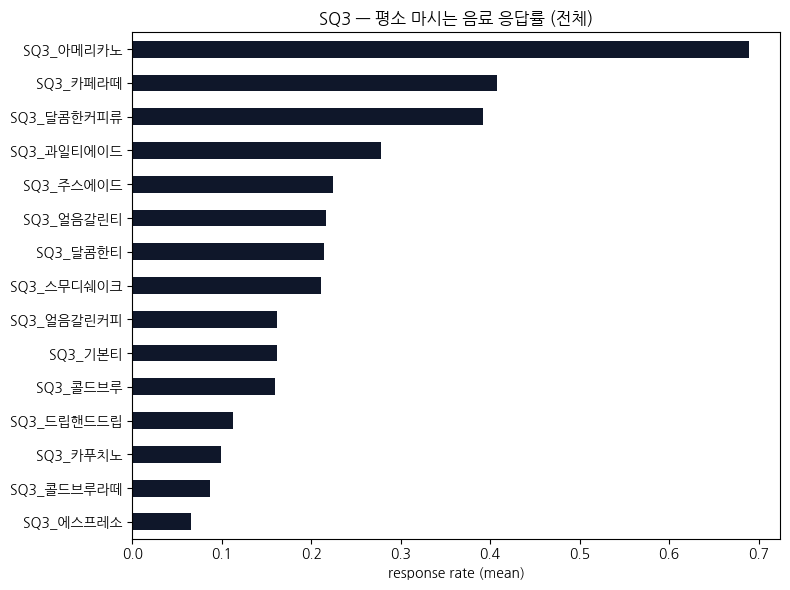

In [119]:
# 전체 SQ3 응답률
sq3_total = survey_df[sq3_cols].mean().sort_values(ascending=False)
print("[SQ3] 전체 응답률 (평소 마시는 음료):")
print(sq3_total.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sq3_total[::-1].plot(kind="barh", ax=ax, color="#0f172a")
ax.set_xlabel("response rate (mean)")
ax.set_title("SQ3 — 평소 마시는 음료 응답률 (전체)")
plt.tight_layout()
plt.show()

In [120]:
# (sex × age_10) 별 SQ3 평균
menu_by_demo = (
    survey_df.groupby(["sex", "age_10"])[sq3_cols]
    .mean().reset_index()
)
menu_by_demo.to_csv(OUTPUT_DIR / "prior_menu_by_demographic.csv", index=False, encoding="utf-8-sig")
print("saved prior_menu_by_demographic.csv shape:", menu_by_demo.shape)
menu_by_demo.head()

saved prior_menu_by_demographic.csv shape: (8, 17)


,sex,age_10,SQ3_에스프레소,SQ3_아메리카노,SQ3_카페라떼,SQ3_카푸치노,SQ3_콜드브루,SQ3_콜드브루라떼,SQ3_드립핸드드립,SQ3_달콤한커피류,SQ3_얼음갈린커피,SQ3_기본티,SQ3_달콤한티,SQ3_과일티에이드,SQ3_얼음갈린티,SQ3_스무디쉐이크,SQ3_주스에이드
0,남,20대,0.062500,0.701923,0.399038,0.062500,0.173077,0.057692,0.139423,0.288462,0.149038,0.115385,0.168269,0.274038,0.250000,0.182692,0.182692
1,남,30대,0.057613,0.707819,0.296296,0.106996,0.176955,0.074074,0.135802,0.345679,0.152263,0.086420,0.139918,0.255144,0.213992,0.164609,0.205761
2,남,40대,0.096296,0.711111,0.337037,0.114815,0.181481,0.074074,0.092593,0.325926,0.122222,0.118519,0.144444,0.192593,0.200000,0.240741,0.200000
3,남,50대,0.078689,0.659016,0.367213,0.095082,0.193443,0.081967,0.118033,0.354098,0.127869,0.170492,0.177049,0.242623,0.193443,0.216393,0.209836
4,여,20대,0.041667,0.703125,0.453125,0.104167,0.182292,0.104167,0.078125,0.437500,0.250000,0.156250,0.338542,0.338542,0.260417,0.182292,0.244792


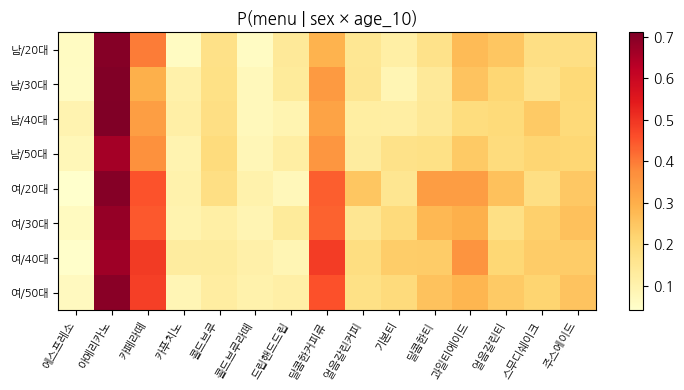

In [121]:
# 히트맵
pivot = menu_by_demo.set_index(["sex","age_10"])[sq3_cols]
fig, ax = plt.subplots(figsize=(min(len(sq3_cols)*0.5, 16), max(pivot.shape[0]*0.4, 4)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(sq3_cols)))
ax.set_xticklabels([c.replace("SQ3_","") for c in sq3_cols], rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([f"{a}/{b}" for a,b in pivot.index], fontsize=8)
ax.set_title("P(menu | sex × age_10)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5. 자주 가는 카페 브랜드 (SQ4 + visit_*) × 인구통계 → `prior_brand_by_demographic.csv`

In [122]:
if sq4_cols:
    print("[SQ4] 1순위 분포:")
    print(survey_df[sq4_cols[0]].value_counts(dropna=False).head(15).to_string())

if visit_cols:
    print("\n[visit_*] 카페별 방문 비율:")
    print(survey_df[visit_cols].mean().sort_values(ascending=False).to_string())

[SQ4] 1순위 분포:
SQ4_1순위
아메리카노     921
달콤한커피류    277
카페라떼      230
과일티에이드    101
얼음갈린티      84
스무디쉐이크     68
주스에이드      65
콜드브루       57
달콤한티       50
얼음갈린커피     38
기본티        35
NaN        25
드립핸드드립     21
카푸치노       11
에스프레소      10

[visit_*] 카페별 방문 비율:
visit_메가커피      0.4305
visit_컴포즈커피     0.4125
visit_이디야       0.4025
visit_투썸플레이스    0.4025
visit_스타벅스      0.3990
visit_뺵다방       0.3860


In [123]:
if visit_cols:
    brand_by_demo = (
        survey_df.groupby(["sex","age_10"])[visit_cols].mean().reset_index()
    )
    brand_by_demo.to_csv(OUTPUT_DIR / "prior_brand_by_demographic.csv", index=False, encoding="utf-8-sig")
    print("saved prior_brand_by_demographic.csv shape:", brand_by_demo.shape)
    brand_by_demo.head()

saved prior_brand_by_demographic.csv shape: (8, 8)


## 6. 시간대 (Q8) — `prior_time_by_demographic.csv`

[Q8] 시간대별 방문 응답률 (모든 카페 평균):
평일점심    0.184700
평일오후    0.127172
평일저녁    0.125528
주말오후    0.117127
주말점심    0.094766
평일오전    0.090715
평일아침    0.066245
주말오전    0.055478
주말저녁    0.053933
평일밤     0.028223
주말밤     0.016923
주말아침    0.011982


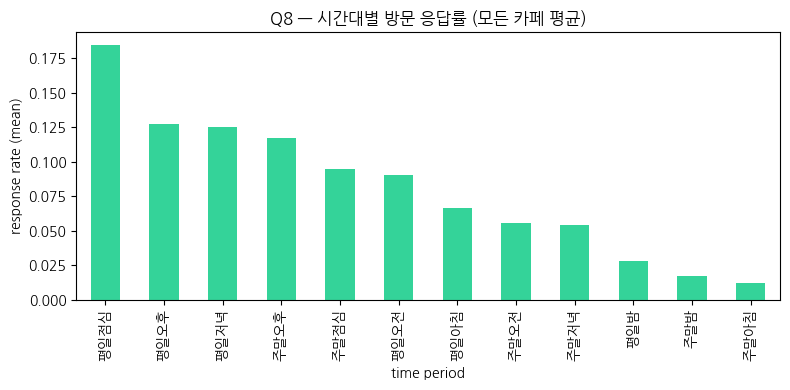

In [124]:
# 모든 카페에 걸친 시간대별 방문 응답률 평균
time_avg = {}
for t in times_q8:
    cols = [c for c in q8_cols if c.endswith(f"_Q8_{t}")]
    if cols:
        time_avg[t] = survey_df[cols].mean().mean()
time_avg = pd.Series(time_avg).sort_values(ascending=False)
print("[Q8] 시간대별 방문 응답률 (모든 카페 평균):")
print(time_avg.to_string())

fig, ax = plt.subplots(figsize=(8,4))
time_avg.plot(kind="bar", ax=ax, color="#34d399")
ax.set_xlabel("time period")
ax.set_ylabel("response rate (mean)")
ax.set_title("Q8 — 시간대별 방문 응답률 (모든 카페 평균)")
plt.tight_layout()
plt.show()

In [125]:
# (sex × age_10) × time_period 평균
rows = []
for t in times_q8:
    cols = [c for c in q8_cols if c.endswith(f"_Q8_{t}")]
    if not cols:
        continue
    g = survey_df.groupby(["sex","age_10"])[cols].mean().mean(axis=1).reset_index(name="rate")
    g["time_period"] = t
    rows.append(g)
time_by_demo = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
time_by_demo.to_csv(OUTPUT_DIR / "prior_time_by_demographic.csv", index=False, encoding="utf-8-sig")
print("saved prior_time_by_demographic.csv shape:", time_by_demo.shape)
time_by_demo.head()

saved prior_time_by_demographic.csv shape: (96, 4)


,sex,age_10,rate,time_period
0,남,20대,0.023174,주말밤
1,남,30대,0.011889,주말밤
2,남,40대,0.010607,주말밤
3,남,50대,0.020265,주말밤
4,여,20대,0.020313,주말밤


## 7. 메뉴 (Q9) × 시간대 (Q8) → `prior_menu_by_time.csv`

Q9는 `<카페>_Q9_<메뉴>` 형태. Q8는 `<카페>_Q8_<시간대>` 형태.
동일 응답자에서 Q9 메뉴와 Q8 시간대 둘 다 1인 경우의 빈도로 P(menu | time) 추정.

In [126]:
# 응답자별로 (cafe, menu) flatten + (cafe, time) flatten 후 inner-cafe로 결합
rows = []
for menu in menus_q9:
    cols_m = [c for c in q9_cols if c.endswith(f"_Q9_{menu}")]
    if not cols_m:
        continue
    menu_signal = survey_df[cols_m].sum(axis=1) > 0  # 어떤 카페에서든 그 메뉴를 마심
    for t in times_q8:
        cols_t = [c for c in q8_cols if c.endswith(f"_Q8_{t}")]
        if not cols_t:
            continue
        time_signal = survey_df[cols_t].sum(axis=1) > 0
        joint = (menu_signal & time_signal).sum()
        time_only = time_signal.sum()
        prob = joint / time_only if time_only > 0 else 0.0
        rows.append({"menu": menu, "time_period": t, "P_menu_given_time": prob,
                     "joint_count": int(joint), "time_count": int(time_only)})
menu_by_time = pd.DataFrame(rows)
menu_by_time.to_csv(OUTPUT_DIR / "prior_menu_by_time.csv", index=False, encoding="utf-8-sig")
print("saved prior_menu_by_time.csv shape:", menu_by_time.shape)
menu_by_time.sort_values("P_menu_given_time", ascending=False).head(20)

saved prior_menu_by_time.csv shape: (84, 5)


,menu,time_period,P_menu_given_time,joint_count,time_count
24,에스프레소베이스,주말밤,1.000000,78,78
25,에스프레소베이스,주말아침,1.000000,57,57
26,에스프레소베이스,주말오전,1.000000,255,255
27,에스프레소베이스,주말오후,1.000000,501,501
28,에스프레소베이스,주말저녁,1.000000,250,250
29,에스프레소베이스,주말점심,1.000000,417,417
30,에스프레소베이스,평일밤,1.000000,132,132
31,에스프레소베이스,평일아침,1.000000,312,312
35,에스프레소베이스,평일점심,1.000000,766,766
34,에스프레소베이스,평일저녁,1.000000,536,536


## 8. rec_items.csv 보조 분석 (메뉴 메타 검증)

In [127]:
print(items_df.shape)
print(items_df.columns.tolist())
items_df.head()

(30, 10)
['item_id', 'item_name', 'category', 'is_hot', 'is_ice', 'is_coffee', 'caffeine_mg', 'sugar_g', 'calorie_kcal', 'base_price']


,item_id,item_name,category,is_hot,is_ice,is_coffee,caffeine_mg,sugar_g,calorie_kcal,base_price
0,I001,에스프레소,에스프레소베이스,1,0,1,130,26.5,2,4580
1,I002,아메리카노(HOT),에스프레소베이스,1,0,1,147,32.4,6,5392
2,I003,아메리카노(ICE),에스프레소베이스,0,1,1,177,23.3,88,4140
3,I004,콜드브루,에스프레소베이스,0,1,1,135,20.4,63,4801
4,I005,드립커피,에스프레소베이스,1,0,1,144,22.9,65,4361


## 9. 외부 reference 검증 (Phase 1.2)

본 섹션은 OpenSurvey 분포가 실제 카페 시장과 어긋나지 않는지 정량 비교한다.
사용 가능한 reference:
- (필수) **노트북 01의 Bread Basket 시간대 분포** — 영국식이지만 카페 운영 시간 패턴 reference.
- (선택) **Coffee Sales Dataset** — 미국 카페 시간대 분포.
- (정성) NIQ Korea / Simon-Kucher PDF — 직접 수치 비교는 어려움, 정성 메모만.

Bread Basket 정제본이 Drive/로컬에 있으면 자동 로드. 없으면 검증 섹션은 skip.

[Bread Basket — hour distribution]
hour
1     0.000
7     0.002
8     0.040
9     0.106
10    0.134
11    0.152
12    0.140
13    0.121
14    0.118
15    0.097
16    0.061
17    0.017
18    0.005
19    0.004
20    0.002
21    0.000
22    0.001
23    0.000


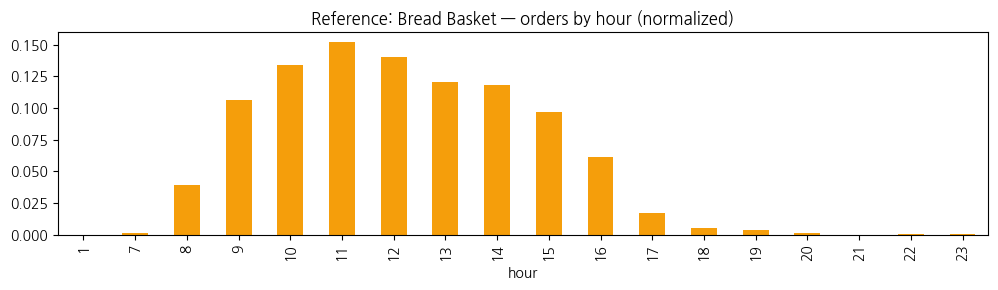

In [128]:
BREAD_PATH = OUTPUT_DIR / "transactions_clean.csv"
validation_lines = ["# Validation Report — OpenSurvey vs External References", ""]

if BREAD_PATH.exists():
    bread = pd.read_csv(BREAD_PATH, parse_dates=["datetime"])
    bread_hour = bread.drop_duplicates("Transaction").groupby("hour").size()
    bread_hour = bread_hour / bread_hour.sum()

    # OpenSurvey의 시간대 → 시 단위는 직접 매핑 어려움. 시간대 라벨끼리 비교 (정성).
    print("[Bread Basket — hour distribution]")
    print(bread_hour.round(3).to_string())
    fig, ax = plt.subplots(figsize=(10,3))
    bread_hour.plot(kind="bar", ax=ax, color="#f59e0b")
    ax.set_title("Reference: Bread Basket — orders by hour (normalized)")
    plt.tight_layout(); plt.show()
    validation_lines.append(f"## Bread Basket reference\nPeak hour: {int(bread_hour.idxmax())}h\n")
else:
    print("[skip] transactions_clean.csv 없음 — 노트북 01 결과를 OUTPUT_DIR에 두면 비교 활성화.")
    validation_lines.append("## Bread Basket reference: SKIPPED (file missing)\n")

[Coffee Sales — hour distribution]
hour
6     0.001
7     0.025
8     0.066
9     0.068
10    0.092
11    0.080
12    0.068
13    0.063
14    0.063
15    0.067
16    0.078
17    0.067
18    0.061
19    0.065
20    0.048
21    0.055
22    0.032


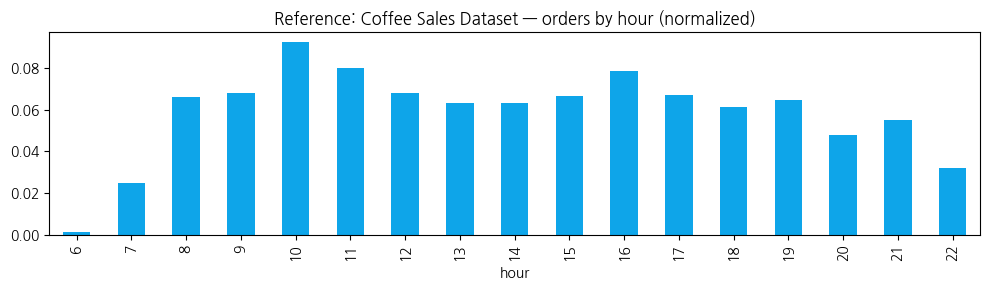

In [129]:
COFFEE_PATH = BASE_DIR  / "Coffe_sales.csv"
if COFFEE_PATH.exists():
    coffee = read_csv_smart(COFFEE_PATH)
    coffee["hour"] = pd.to_numeric(coffee.get("hour_of_day", coffee.get("hour", 0)), errors="coerce")
    h = coffee["hour"].dropna().astype(int).value_counts().sort_index()
    h = h / h.sum()
    print("[Coffee Sales — hour distribution]")
    print(h.round(3).to_string())
    fig, ax = plt.subplots(figsize=(10,3))
    h.plot(kind="bar", ax=ax, color="#0ea5e9")
    ax.set_title("Reference: Coffee Sales Dataset — orders by hour (normalized)")
    plt.tight_layout(); plt.show()
    validation_lines.append(f"## Coffee Sales reference\nPeak hour: {int(h.idxmax())}h\n")
else:
    print("[skip] Coffee Sales 파일 없음 — 검증 활용 안함.")
    validation_lines.append("## Coffee Sales reference: SKIPPED\n")

In [130]:
validation_lines.append("\n## Summary\n")
validation_lines.append("- OpenSurvey 인구통계: 자기검증 (표집 그대로 사용)\n")
validation_lines.append("- 시간대 분포: Bread Basket / Coffee Sales 두 reference의 피크 시간이 OpenSurvey의 'Q8 점심/오전' 응답률 피크와 정성적으로 일치하는지 확인\n")
validation_lines.append("- 메뉴 카테고리 비중 / 효과 크기: 자료조사 PDF에 명시된 수치와 합성 단계(노트북 03)에서 비교\n")

report_path = OUTPUT_DIR / "validation_report.md"
report_path.write_text("".join(validation_lines), encoding="utf-8")
print("saved:", report_path)
print("".join(validation_lines))

saved: /content/drive/MyDrive/광운대 /26년도 캡스톤/data/output/validation_report.md
# Validation Report — OpenSurvey vs External References## Bread Basket reference
Peak hour: 11h
## Coffee Sales reference
Peak hour: 10h

## Summary
- OpenSurvey 인구통계: 자기검증 (표집 그대로 사용)
- 시간대 분포: Bread Basket / Coffee Sales 두 reference의 피크 시간이 OpenSurvey의 'Q8 점심/오전' 응답률 피크와 정성적으로 일치하는지 확인
- 메뉴 카테고리 비중 / 효과 크기: 자료조사 PDF에 명시된 수치와 합성 단계(노트북 03)에서 비교



## 10. 다운로드

직접 업로드 모드일 때 산출물을 로컬로 내려받는다.

In [131]:
if not USE_GDRIVE:
    try:
        from google.colab import files
        for name in ["prior_demographics.csv",
                     "prior_menu_by_demographic.csv",
                     "prior_brand_by_demographic.csv",
                     "prior_time_by_demographic.csv",
                     "prior_menu_by_time.csv",
                     "validation_report.md"]:
            p = OUTPUT_DIR / name
            if p.exists():
                files.download(str(p))
    except Exception as e:
        print("download skipped (non-Colab env):", e)

## 11. 다음 단계

1. 본 노트북 산출 5종 prior CSV + validation_report 검토.
2. 검증에서 어긋난 부분이 있으면 다음 노트북(`03_build_and_validate_synthetic.ipynb`)의 합성 SPEC에 보정 메모로 반영.
3. 노트북 03에서 자체 합성 실행 → 검증 → Phase 2(모델 학습)로 진입.